In [1]:
import cv2
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
from tensorflow.keras.models import load_model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models


In [2]:
# Пути
DATA_DIR = '/Users/nick/projects/AI_DB/1 lab/fruit_dataset'

# Создание модели EfficientNet
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
output = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs=base_model.input, outputs=output)

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print('Модель EfficientNet создана')


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Модель EfficientNet создана


In [3]:
# Функция Grad-CAM
def make_gradcam_heatmap(img_array, grad_model):
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()


In [4]:
# Найти последний сверточный слой
last_conv_layer = None
for layer in model.layers:
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer = layer

print(f'Последний сверточный слой: {last_conv_layer.name}')

grad_model = tf.keras.models.Model(
    inputs=model.input,
    outputs=[last_conv_layer.output, model.output]
)

print('Grad-CAM модель создана')


Последний сверточный слой: top_conv
Grad-CAM модель создана


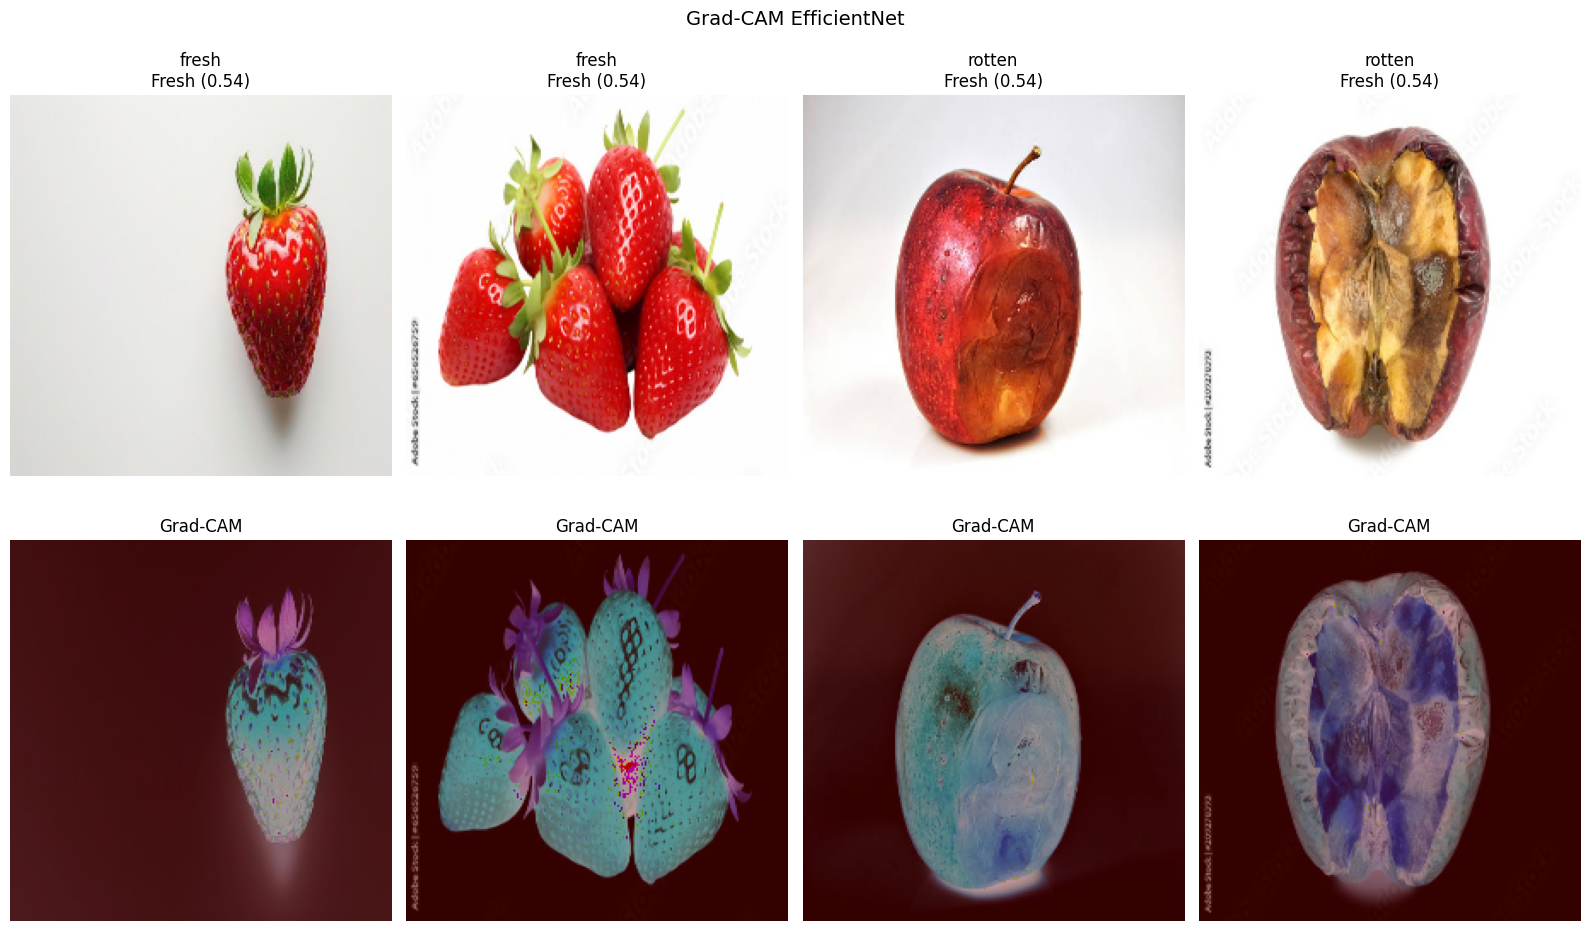

In [9]:
# Визуализация
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
examples = [('fresh', 0), ('fresh', 1), ('rotten', 0), ('rotten', 1)]

for idx, (condition, num) in enumerate(examples):
    folder = os.path.join(DATA_DIR, condition)
    images = [f for f in os.listdir(folder) if f.endswith(('.jpg', '.jpeg', '.png'))]
    if not images:
        continue

    img_path = os.path.join(folder, images[num % len(images)])
    img = plt.imread(img_path)
    img_resized = cv2.resize(img, (224, 224))
    img_array = np.expand_dims(img_resized / 255.0, axis=0)

    pred = model.predict(img_array, verbose=0)
    pred_class = 'Rotten' if pred[0][0] > 0.5 else 'Fresh'
    confidence = pred[0][0] if pred_class == 'Rotten' else 1 - pred[0][0]

    try:
        heatmap = make_gradcam_heatmap(img_array, grad_model)
        heatmap = cv2.resize(heatmap, (224, 224))
        heatmap = np.uint8(255 * heatmap)
        heatmap_colored = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
        superimposed = cv2.addWeighted(np.uint8(img_resized * 255), 0.6, heatmap_colored, 0.4, 0)
    except Exception as e:
        print(f'Ошибка для {condition}: {e}')
        superimposed = np.uint8(img_resized * 255)

    axes[0, idx].imshow(img_resized)
    axes[0, idx].set_title(f'{condition}\n{pred_class} ({confidence:.2f})')
    axes[0, idx].axis('off')

    axes[1, idx].imshow(superimposed)
    axes[1, idx].set_title('Grad-CAM')
    axes[1, idx].axis('off')

plt.suptitle('Grad-CAM EfficientNet', fontsize=14)
plt.tight_layout()
plt.show()
